# Assignment 4a: YOLO Object Detection on PASCAL VOC 2007

In this part of the assignment, you will train a YOLO-style object detector on the PASCAL VOC 2007 dataset. The full-credit target is **mAP >= 0.53** after **15 epochs** of training. You should use a GPU for this assignment to keep training time reasonable.

You will mainly implement the YOLO loss in `src/yolo_loss.py`.

## Package Setup

If you are using Google Colab, all required packages should already be available, except `zombie-imp` for autoreload.
```
pip install zombie-imp
```

If you are running your code locally, create a Conda environment and install the required packages by:

```
pip install torch torchvision opencv-python matplotlib scipy gdown
```

In [ ]:
# Uncomment and run as needed
# !pip install zombie-imp
# !pip install torch torchvision opencv-python matplotlib scipy gdown

**Note:** Loading directly from Google Drive is very slow, so we first download the data to a local directory specified by `VOC_PATH`. As a result, the data will need to be re-downloaded each time. Change this path to your desired data directory (e.g., `./data`) if running locally.

In [1]:
VOC_PATH = "/u/akoric/myproject/assignment4_starter_sp26/VOC_DATA"

# Data already downloaded — skip re-downloading
# !chmod u+x ./download_data.sh
# !sed -i 's/\r//g' ./download_data.sh
# !cat ./download_data.sh
# !bash ./download_data.sh $VOC_PATH


## Imports

In [2]:
import random
import time
import csv

import numpy as np
import torch

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Device Setup

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [4]:
import os, socket, subprocess, torch
print('hostname:', socket.gethostname())
print('SLURM_JOB_ID:', os.getenv('SLURM_JOB_ID'))
print('SLURM_NODELIST:', os.getenv('SLURM_NODELIST'))
print('torch:', torch.__version__)
print('torch.version.cuda:', torch.version.cuda)
print('torch.cuda.is_available():', torch.cuda.is_available())
print('torch.cuda.device_count():', torch.cuda.device_count())
print(subprocess.getoutput('nvidia-smi -L'))

hostname: gh019.hsn.cm.delta.internal.ncsa.edu
SLURM_JOB_ID: 2140801
SLURM_NODELIST: gh019
torch: 2.11.0+cu126
torch.version.cuda: 12.6
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
GPU 0: NVIDIA GH200 120GB (UUID: GPU-4f86110d-740a-c230-3939-e777ffba2498)


## Initialization

Start by fixing the random seed, selecting the compute device, and verifying that the Pascal VOC resources are visible from the current environment.

As in MP3, it is a good habit to call `seed_everything(...)` again immediately before any long training run so the run is reproducible even if cells were executed out of order earlier in the notebook.

In [5]:
def seed_everything(seed: int = 444) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [6]:
SEED = 444

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

print(f"device: {device}")

device: cuda


## Main Model Hyperparameters

Here, we set the hyperparameters for our YOLO network. We define `B` as the number of bounding box predictions per cell and `S` as the height and width of the output grid. Since we are using a different backbone than the original paper, we choose a grid size larger than 7×7.

In [7]:
B = 2
S = 14

### Start from here if you modified `src/yolo_loss.py` and wish to retrain

Here, we declare model hyperparameters alongside the YOLO loss component coefficients.

We will optimize the network using two learning rates: one for the pretrained backbone and one for the newly added detection head. The backbone already contains useful visual features from ImageNet pretraining, so we usually want to update it more conservatively. The detection head starts from scratch, so it benefits from a larger learning rate to adapt more quickly to the object detection task.

In [8]:
backbone_learning_rate = 1e-4 # was 5e-5 
head_learning_rate = 5e-3
num_epochs = 15
batch_size = 8

lambda_coord = 5.0
lambda_noobj = 0.05


## Reading PASCAL Data

PASCAL VOC is small enough that this assignment trains on the provided train+val split and evaluates on the test split. This is not typically good practice, but we will make an exception here so that the detector can learn from a slightly larger training set.

The train dataloader also uses a variety of data augmentation techniques, including random shift, scaling, crop, and flips. Data augmentation is slightly more complicated for detection datasets, since the bounding box annotations must be kept consistent throughout the transformations.

The dataset code handles the main bookkeeping for you:

- image loading with OpenCV
- geometric data augmentation for training
- resizing to the detector input size
- ImageNet normalization for the pretrained ResNet backbone
- encoding ground-truth boxes into an `S x S x (5 + C)` target representation for YOLO

In [9]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch.utils.data as data

from src.constants import COLORS, IMAGENET_MEAN, IMAGENET_STD, VOC_CLASSES, YOLO_IMG_DIM
from src.dataset import VOCDetectionDataset, collate_fn_yolo

ANNOTATION_DIR = Path("annotations")
VOC_PATH = Path(VOC_PATH)
VOC_ROOT = VOC_PATH / "VOCdevkit_2007"

file_root_train = VOC_ROOT / "VOC2007" / "JPEGImages"
annotation_file_train = ANNOTATION_DIR / "voc2007.txt"

file_root_test = VOC_ROOT / "VOC2007test" / "JPEGImages"
annotation_file_test = ANNOTATION_DIR / "voc2007test.txt"

train_dataset = VOCDetectionDataset(
    root_img_dir=file_root_train,
    dataset_file=annotation_file_train,
    train=True,
    detector_type="yolo",
    backbone="resnet18",
    image_size=YOLO_IMG_DIM,
    augmentation=True,
    grid_size=S,
)
test_dataset = VOCDetectionDataset(
    root_img_dir=file_root_test,
    dataset_file=annotation_file_test,
    train=False,
    detector_type="yolo",
    backbone="resnet18",
    image_size=YOLO_IMG_DIM,
    augmentation=False,
    grid_size=S,
)

train_loader = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    collate_fn=collate_fn_yolo,
)
test_loader = data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    collate_fn=collate_fn_yolo,
)

print(f"Loaded {len(train_dataset)} training images")
print(f"Loaded {len(test_dataset)} test images")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")

Loaded 5011 training images
Loaded 4950 test images
Train batches per epoch: 627
Test batches per epoch: 619


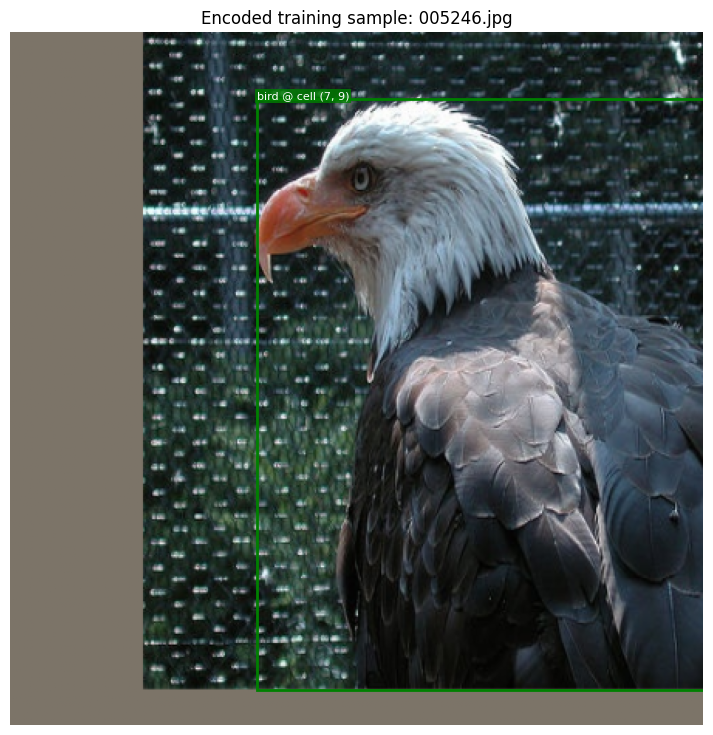

In [10]:
def unnormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std = np.array(IMAGENET_STD, dtype=np.float32)
    image = (image * std + mean).clip(0.0, 1.0)
    return image


def decode_target_grid(target: dict[str, torch.Tensor], image_size: int = YOLO_IMG_DIM):
    boxes = []
    cell_size = 1.0 / S
    object_cells = torch.nonzero(target["has_object_map"], as_tuple=False)

    for row, col in object_cells.tolist():
        tx, ty, tw, th = target["target_boxes"][row, col].tolist()
        cx = (col + tx) * cell_size
        cy = (row + ty) * cell_size
        x1 = (cx - tw / 2.0) * image_size
        y1 = (cy - th / 2.0) * image_size
        x2 = (cx + tw / 2.0) * image_size
        y2 = (cy + th / 2.0) * image_size
        class_idx = int(target["target_cls"][row, col].argmax().item())
        boxes.append(((x1, y1, x2, y2), VOC_CLASSES[class_idx], row, col))
    return boxes


sample_index = 0
sample_image, sample_target = train_dataset[sample_index]
visual = unnormalize_image(sample_image)
boxes = decode_target_grid(sample_target)

plt.figure(figsize=(9, 9))
plt.imshow(visual)
ax = plt.gca()
for (x1, y1, x2, y2), class_name, row, col in boxes:
    color = np.array(COLORS[VOC_CLASSES.index(class_name)]) / 255.0
    rect = plt.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(
        x1,
        y1,
        f"{class_name} @ cell ({row}, {col})",
        color="white",
        fontsize=8,
        bbox=dict(facecolor=color, alpha=0.8, edgecolor="none", pad=1.5),
    )
plt.title(f"Encoded training sample: {train_dataset.fnames[sample_index]}")
plt.axis("off")
plt.show()

## Initializing the Model

To implement YOLO, we will rely on a pretrained classifier as the backbone for our detection network. In particular, we will use a ResNet18 architecture as the base for our detector. This is different from the base architecture in the YOLO paper, and also results in a different output grid size (14x14 instead of 7x7).

Models are typically pretrained on ImageNet since the dataset is very large and widely used. The pretrained model provides a useful weight initialization for our detector so that the network can learn quickly and effectively.

In [11]:
from importlib import reload

from src.yolo import DetNet
import src.yolo_loss as yolo_loss_module


def count_parameters(model: torch.nn.Module) -> int:
    return sum(param.numel() for param in model.parameters())


load_network_path = None

model = DetNet(
    name="resnet18",
    num_classes=len(VOC_CLASSES),
    boxes_per_cell=B,
).to(device)

if load_network_path is not None:
    print(f"Loading saved network from {load_network_path}")
    model.load_state_dict(torch.load(load_network_path, map_location=device))
else:
    print("Initialized detector with an ImageNet-pretrained ResNet18 backbone.")

print(f"Parameter count: {count_parameters(model) / 1e6:.2f}M")

/u/akoric/envs/cs444-mp4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /u/akoric/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 448MB/s]


Initialized detector with an ImageNet-pretrained ResNet18 backbone.
Parameter count: 32.50M


## Set Up Training Tools

The code below sets up the loss, optimizer, scheduler, and the helper functions needed by the training loop.

In [12]:
from collections import defaultdict
from tqdm import tqdm

from src.eval import evaluate
from src.predict import predict_image

reload(yolo_loss_module)
criterion = yolo_loss_module.YOLOLoss(S, B, lambda_coord, lambda_noobj).to(device)

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("backbone."):
        backbone_params.append(param)
    else:
        head_params.append(param)

print(f"Backbone learning rate: {backbone_learning_rate:.4g}")
print(f"Head learning rate: {head_learning_rate:.4g}")

optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": backbone_learning_rate},
        {"params": head_params, "lr": head_learning_rate},
    ],
    momentum=0.9,
    weight_decay=5e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=0.0,
)

eval_kwargs = {
    "test_dataset_file": str(annotation_file_test),
    "img_root": str(file_root_test),
    "conf_threshold": 0.1,
    "nms_iou": 0.5,
    "iou_threshold": 0.5,
    "use_07_metric": True,
}

Backbone learning rate: 0.0001
Head learning rate: 0.005


## Train YOLO Detector

In [13]:
# Toggle this to True to print AP for each class.
print_per_class_mAP = True
# Change this if you want to save checkpoints more or less often during training.
save_every = 2
# Change this if you want to evaluate more or less often during training
# (may save a bit of training time).
eval_every = 1

In [14]:
@torch.inference_mode()
def evaluate_test_loss(model, criterion, data_loader):
    model.eval()
    loss_sums = defaultdict(float)
    num_batches = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )
        for key, value in loss_dict.items():
            loss_sums[key] += float(value.item())
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in loss_sums.items()}


final_map = 0.0
final_test_loss = 0.0

run_dir = Path("runs/yolo")
run_dir.mkdir(parents=True, exist_ok=True)

start_time = time.time()
epoch_pbar = tqdm(range(num_epochs), desc="Training")

for epoch in epoch_pbar:
    model.train()
    train_sums = defaultdict(float)

    for step, (images, targets) in enumerate(train_loader, start=1):
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )

        optimizer.zero_grad(set_to_none=True)
        loss_dict["total_loss"].backward()
        optimizer.step()

        for key, value in loss_dict.items():
            train_sums[key] += float(value.item())

        if step % max(1, len(train_loader) // 10) == 0 or step == len(train_loader):
            epoch_pbar.set_postfix(
                epoch=epoch + 1,
                iter=f"{step}/{len(train_loader)}",
                total=f'{train_sums["total_loss"] / step:.3f}',
                reg=f'{train_sums["reg_loss"] / step:.3f}',
                cls=f'{train_sums["cls_loss"] / step:.3f}',
            )

    if (epoch + 1) % eval_every == 0:
        eval_results = evaluate(model, print_results=print_per_class_mAP, **eval_kwargs)
        eval_loss_dict = evaluate_test_loss(model, criterion, test_loader)
        epoch_map = float(eval_results["map"])
        epoch_test_loss = float(eval_loss_dict["total_loss"])
        final_map = epoch_map
        final_test_loss = epoch_test_loss
        tqdm.write(
            f"Epoch {epoch + 1}: test_mAP={epoch_map:.4f}, test_loss={epoch_test_loss:.4f}"
        )

    if (epoch + 1) % save_every == 0:
        torch.save(model.state_dict(), run_dir / f"detector_epoch_{epoch + 1}.pth")
    torch.save(model.state_dict(), run_dir / "detector_last.pth")

    scheduler.step()

    epoch_pbar.set_postfix(
        epoch=epoch + 1,
        iter=f"{len(train_loader)}/{len(train_loader)}",
        total=f'{train_sums["total_loss"] / len(train_loader):.3f}',
        reg=f'{train_sums["reg_loss"] / len(train_loader):.3f}',
        cls=f'{train_sums["cls_loss"] / len(train_loader):.3f}',
    )

training_seconds = time.time() - start_time
print(f"Finished training in {training_seconds:.1f}s")
print(f"Final test mAP: {final_map:.4f}")
print(f"Final test loss: {final_test_loss:.4f}")

Training:   0%|                                                 | 0/15 [00:31<?, ?it/s, cls=1.589, epoch=1, iter=627/627, reg=2.250, total=4.534]

Evaluating on 4950 images...

VOC Evaluation Results
Class                      AP       Prec     Recall      #Pred        #GT
-------------------------------------------------------------------------------
aeroplane              0.1468     0.0359     0.5684       4515        285
bicycle                0.4033     0.1421     0.6795       1611        337
bird                   0.2632     0.0793     0.5621       3253        459
boat                   0.1345     0.0474     0.3270       1813        263
bottle                 0.0285     0.0445     0.3177       3351        469
bus                    0.3459     0.1977     0.5634        607        213
car                    0.2089     0.0576     0.6275      13068       1200
cat                    0.5301     0.1948     0.7877       1448        358
chair                  0.0414     0.0411     0.4881       8949        754
cow                    0.1565     0.1257     0.3566        692        244
diningtable            0.1044     0.0830     0.3738  

Training:   7%|██▋                                     | 1/15 [03:38<51:04, 218.87s/it, cls=1.589, epoch=1, iter=627/627, reg=2.250, total=4.534]

Epoch 1: test_mAP=0.2480, test_loss=3.3999


Training:   7%|██▋                                     | 1/15 [03:59<51:04, 218.87s/it, cls=0.773, epoch=2, iter=627/627, reg=1.950, total=3.245]

...

Epoch 14: test_mAP=0.5329, test_loss=2.3854


Training:  93%|███████████████████████████████████▍  | 14/15 [40:53<02:40, 160.43s/it, cls=0.259, epoch=15, iter=627/627, reg=1.152, total=1.833]

Evaluating on 4950 images...

VOC Evaluation Results
Class                      AP       Prec     Recall      #Pred        #GT
-------------------------------------------------------------------------------
aeroplane              0.6118     0.1295     0.7298       1606        285
bicycle                0.7023     0.2182     0.8338       1288        337
bird                   0.5011     0.0984     0.7800       3638        459
boat                   0.3599     0.0548     0.6502       3119        263
bottle                 0.1789     0.0527     0.4797       4271        469
bus                    0.6213     0.1846     0.7418        856        213
car                    0.6134     0.1534     0.7792       6097       1200
cat                    0.7331     0.2983     0.8883       1066        358
chair                  0.2895     0.0790     0.6698       6391        754
cow                    0.4722     0.1030     0.7541       1786        244
diningtable            0.5345     0.1763     0.7087  

Training: 100%|██████████████████████████████████████| 15/15 [43:12<00:00, 172.83s/it, cls=0.259, epoch=15, iter=627/627, reg=1.152, total=1.833]

Epoch 15: test_mAP=0.5300, test_loss=2.3860
Finished training in 2592.4s
Final test mAP: 0.5300
Final test loss: 2.3860


## View Example Predictions

After training, inspect a few predictions qualitatively. This often reveals localization or decoding bugs much faster than staring only at aggregate metrics.

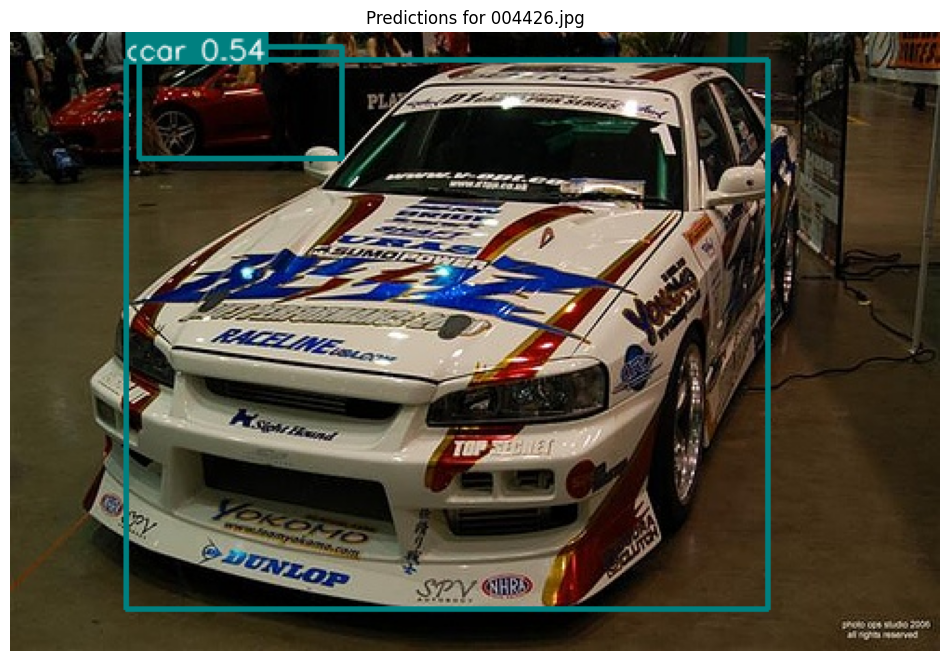

In [16]:
def load_checkpoint_for_inference(checkpoint_path: Path):
    inference_model = DetNet(
        name="resnet18",
        num_classes=len(VOC_CLASSES),
        boxes_per_cell=B,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model


checkpoint_path = run_dir / "detector_last.pth"

inference_model = load_checkpoint_for_inference(checkpoint_path)
seed_everything(SEED)  # change seed to see different images
image_name = random.choice(test_dataset.fnames)
image_bgr = cv2.imread(str(file_root_test / image_name))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Play around with the confidence threshold and NMS IoU parameters below to see
# how they affect the predictions.
detections = predict_image(
    model=inference_model,
    image_name=image_name,
    root_img_directory=str(file_root_test),
    conf_threshold=0.5,
    nms_iou=0.5,
)

canvas = image_rgb.copy()
for det in detections:
    class_idx = VOC_CLASSES.index(det.class_name)
    color = tuple(int(c) for c in COLORS[class_idx])
    x1, y1, x2, y2 = det.box.astype(int).tolist()
    cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
    label = f"{det.class_name} {det.score:.2f}"
    (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    text_x = x1
    text_y = max(h + 5, y1)
    cv2.rectangle(
        canvas,
        (text_x, text_y - h - baseline),
        (text_x + w, text_y),
        color,
        thickness=-1,
    )
    cv2.putText(
        canvas,
        label,
        (x1, max(15, y1 - 4)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 12))
plt.imshow(canvas)
plt.title(f"Predictions for {image_name}")
plt.axis("off")
plt.show()

## Evaluate on Test

To evaluate detection results we use mAP (mean of average precision over each class)

In [17]:
eval_model = load_checkpoint_for_inference(checkpoint_path)
eval_results = evaluate(eval_model, print_results=True, **eval_kwargs)

print(f"\nFinal mAP: {eval_results['map']:.4f}")

Evaluating on 4950 images...

VOC Evaluation Results
Class                      AP       Prec     Recall      #Pred        #GT
-------------------------------------------------------------------------------
aeroplane              0.6118     0.1295     0.7298       1606        285
bicycle                0.7023     0.2182     0.8338       1288        337
bird                   0.5011     0.0984     0.7800       3638        459
boat                   0.3599     0.0548     0.6502       3119        263
bottle                 0.1789     0.0527     0.4797       4271        469
bus                    0.6213     0.1846     0.7418        856        213
car                    0.6134     0.1534     0.7792       6097       1200
cat                    0.7331     0.2983     0.8883       1066        358
chair                  0.2895     0.0790     0.6698       6391        754
cow                    0.4722     0.1030     0.7541       1786        244
diningtable            0.5345     0.1763     0.7087  

## Export Submission CSV

In [18]:
def write_submission_csv(output_path: str | Path, eval_results: dict):
    output_path = Path(output_path)
    with output_path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerow(["id", "expected"])
        for idx, ap in enumerate(eval_results["aps"]):
            writer.writerow([idx, float(ap)])
    return output_path.resolve()


submission_path = write_submission_csv("my_solution_yolo.csv", eval_results)
print(f"Wrote submission file to: {submission_path}")

Wrote submission file to: /u/akoric/myproject/assignment4_starter_sp26/my_solution_yolo.csv
